# EDA and Data Preprocessing

In [ ]:
import sys
from pathlib import Path

sys.path.append('../src')

sys.modules.pop('data_utils', None)

import matplotlib.pyplot as plt
import pandas as pd

from data_utils import (
    load_raw_data,
    multi_hot_encode_genres,
    build_id_mappings,
    merge_datasets,
    leave_last_n_out_split,
    build_genre_feature_matrix,
    prepare_full_pipeline,
)

## Load Raw Data

In [ ]:
movies, ratings, tags, links = load_raw_data()
movies.shape, ratings.shape, tags.shape, links.shape

((9742, 3), (100836, 4), (3683, 4), (9742, 3))

## Data Cleaning

In [ ]:
quality_report_before = {
    'duplicate movie rows': int(movies.duplicated(subset='movieId').sum()),
    'duplicate rating rows': int(ratings.duplicated(subset=['userId', 'movieId']).sum()),
    'missing tmdbId': int(links['tmdbId'].isnull().sum()),
    'titles with whitespace issues': int((movies['title'] != movies['title'].str.strip()).sum()),
    'titles without a parsable year': int((~movies['title'].str.contains(r'\(\d{4}\)\s*$', regex=True)).sum()),
    'movies with no genres listed': int((movies['genres'] == '(no genres listed)').sum()),
}
quality_report_before

{'duplicate movie rows': 0,
 'duplicate rating rows': 0,
 'missing tmdbId': 8,
 'titles with whitespace issues': 11,
 'titles without a parsable year': 13,
 'movies with no genres listed': 34}

In [ ]:
movies = movies.drop_duplicates(subset='movieId').copy()
movies['title'] = movies['title'].str.strip()
movies['genres'] = movies['genres'].str.strip()
movies['year'] = movies['title'].str.extract(r'\((\d{4})\)\s*$')[0].astype('Int64')

ratings = ratings.drop_duplicates(subset=['userId', 'movieId']).copy()
ratings = ratings[ratings['rating'].between(0.5, 5.0)].reset_index(drop=True)

tags = tags.copy()
tags['tag'] = tags['tag'].astype(str).str.strip()
tags = tags[tags['tag'] != '']
tags = tags.drop_duplicates(subset=['userId', 'movieId', 'tag']).reset_index(drop=True)

links = links.drop_duplicates(subset='movieId').copy()
links['tmdbId'] = links['tmdbId'].astype('Int64')

movies.shape, ratings.shape, tags.shape, links.shape

((9742, 4), (100836, 4), (3683, 4), (9742, 3))

In [ ]:
quality_report_after = {
    'duplicate movie rows': int(movies.duplicated(subset='movieId').sum()),
    'duplicate rating rows': int(ratings.duplicated(subset=['userId', 'movieId']).sum()),
    'missing tmdbId': int(links['tmdbId'].isnull().sum()),
    'titles with whitespace issues': int((movies['title'] != movies['title'].str.strip()).sum()),
    'movies with a parsed year': int(movies['year'].notna().sum()),
    'movies with no genres listed': int((movies['genres'] == '(no genres listed)').sum()),
}
quality_report_after

{'duplicate movie rows': 0,
 'duplicate rating rows': 0,
 'missing tmdbId': 8,
 'titles with whitespace issues': 0,
 'movies with a parsed year': 9729,
 'movies with no genres listed': 34}

### Save cleaned data

In [ ]:
data_dir = Path('../data')

movies.to_csv(data_dir / 'movies.csv', index=False)
ratings.to_csv(data_dir / 'ratings.csv', index=False)
tags.to_csv(data_dir / 'tags.csv', index=False)
links.to_csv(data_dir / 'links.csv', index=False)

print('Cleaned data saved to ../data')

Cleaned data saved to ../data


## EDA

### Rating distribution

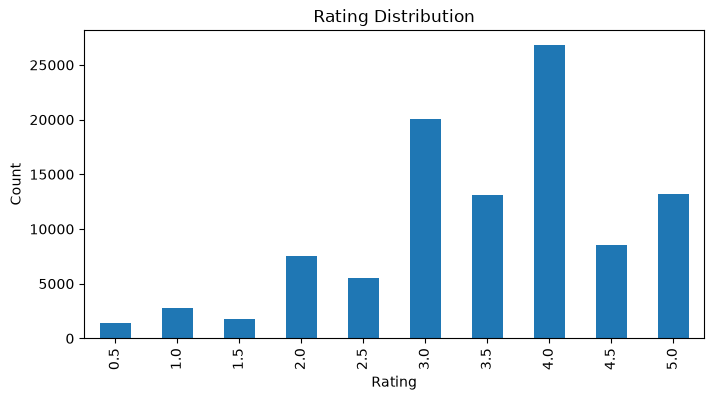

In [ ]:
plt.figure(figsize=(8, 4))
ratings['rating'].value_counts().sort_index().plot(kind='bar')
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

### Sparsity

In [ ]:
num_users = ratings['userId'].nunique()
num_movies = ratings['movieId'].nunique()
num_ratings = len(ratings)
sparsity = 1 - (num_ratings / (num_users * num_movies))
num_users, num_movies, num_ratings, sparsity

(610, 9724, 100836, 0.9830003169443864)

### Ratings per user and per item

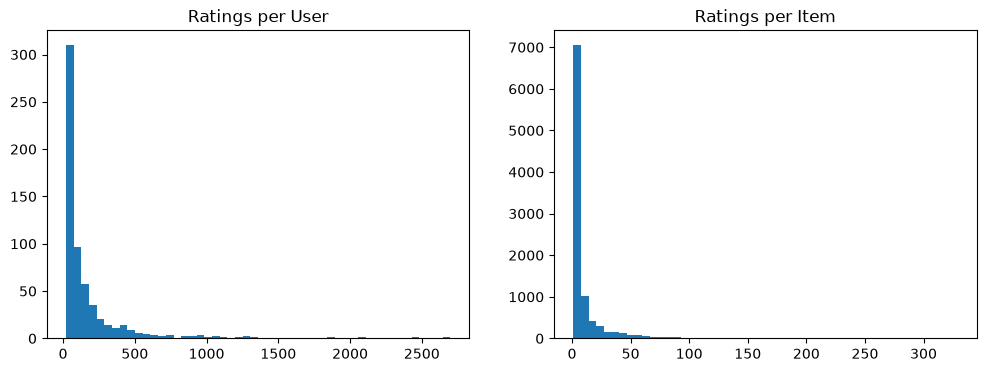

(count     610.000000
 mean      165.304918
 std       269.480584
 min        20.000000
 25%        35.000000
 50%        70.500000
 75%       168.000000
 max      2698.000000
 dtype: float64,
 count    9724.000000
 mean       10.369807
 std        22.401005
 min         1.000000
 25%         1.000000
 50%         3.000000
 75%         9.000000
 max       329.000000
 dtype: float64)

In [ ]:
ratings_per_user = ratings.groupby('userId').size()
ratings_per_item = ratings.groupby('movieId').size()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(ratings_per_user, bins=50)
axes[0].set_title('Ratings per User')
axes[1].hist(ratings_per_item, bins=50)
axes[1].set_title('Ratings per Item')
plt.show()

ratings_per_user.describe(), ratings_per_item.describe()

### Genre distribution

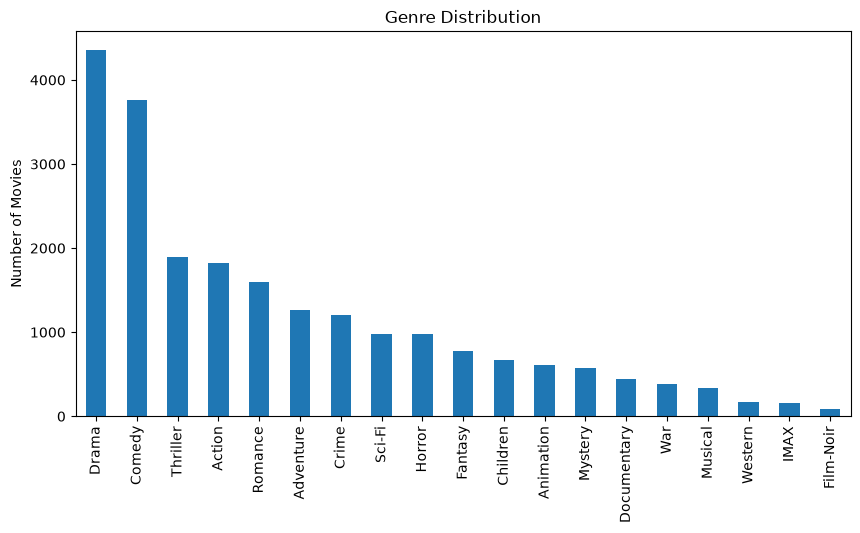

['Action',
 'Adventure',
 'Animation',
 'Children',
 'Comedy',
 'Crime',
 'Documentary',
 'Drama',
 'Fantasy',
 'Film-Noir',
 'Horror',
 'IMAX',
 'Musical',
 'Mystery',
 'Romance',
 'Sci-Fi',
 'Thriller',
 'War',
 'Western']

In [ ]:
movies_encoded, genre_names = multi_hot_encode_genres(movies)
genre_counts = movies_encoded[genre_names].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
genre_counts.plot(kind='bar')
plt.title('Genre Distribution')
plt.ylabel('Number of Movies')
plt.show()

genre_names

### ID mappings

In [ ]:
user_to_idx, idx_to_user, movie_to_idx, idx_to_movie = build_id_mappings(ratings)
len(user_to_idx), len(movie_to_idx), max(user_to_idx.values()), max(movie_to_idx.values())

(610, 9724, 609, 9723)

### Merged dataset preview

In [ ]:
merged = merge_datasets(movies, ratings, links)
merged.head()

,userId,movieId,rating,timestamp,title,genres,year,imdbId,tmdbId
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995,114709,862
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance,1995,113228,15602
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller,1995,113277,949
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,1995,114369,807
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,1995,114814,629


### Leave-last-N-out split per user

In [ ]:
demo_train_df, demo_test_df = leave_last_n_out_split(ratings, n=1, min_ratings=3)
demo_train_df.shape, demo_test_df.shape

((100226, 4), (610, 4))

In [ ]:
sample_user = demo_train_df['userId'].iloc[0]
demo_train_df[demo_train_df['userId'] == sample_user][['userId', 'movieId', 'timestamp']], demo_test_df[demo_test_df['userId'] == sample_user][['userId', 'movieId', 'timestamp']]

(     userId  movieId  timestamp
 0         1      804  964980499
 1         1     1210  964980499
 2         1     2018  964980523
 3         1     2628  964980523
 4         1     2826  964980523
 ..      ...      ...        ...
 226       1      157  964984100
 227       1     1445  964984112
 228       1      553  964984153
 229       1     2478  964984169
 230       1     2012  964984176
 
 [231 rows x 3 columns],
    userId  movieId  timestamp
 0       1     2492  965719662)

### Genre feature matrix

In [ ]:
demo_genre_feature_matrix = build_genre_feature_matrix(movies_encoded, genre_names, movie_to_idx)
demo_genre_feature_matrix.shape

(9724, 19)

### Full pipeline sanity check

In [ ]:
data = prepare_full_pipeline()
{k: (v.shape if hasattr(v, 'shape') else type(v)) for k, v in data.items()}

{'movies': (9742, 4),
 'movies_encoded': (9742, 23),
 'ratings': (100836, 4),
 'tags': (3683, 4),
 'links': (9742, 3),
 'train_df': (100226, 4),
 'test_df': (610, 4),
 'genre_feature_matrix': (9724, 19),
 'mappings': data_utils.Mappings}